# Visualising SSH along SWOT swaths

In [1]:
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cm
from swot_analysis import plotting



In [2]:
#Reading a single file
if False:
    data_dir = '/Users/zoecas/Documents/data/'
    filename = 'SWOT_L2_LR_SSH_Basic_045_216_20260131T225821_20260131T234949_PID0_01.nc'
    
#Reading several swaths files
if True:
    data_dir = Path('/Users/zoecas/Documents/data/SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409')
    files = list(sorted(data_dir.glob('SWOT_L2_LR_SSH_*.nc')))
    print(f'Found {len(list(files))} files')

Found 511 files


In [3]:
#Combining netCDF files in xarray datasets

datasets = [xr.open_dataset(f) for f in files[:50]] #opening files
datasets = [d.where(np.abs(d.ssha_karin)<2.5) for d in datasets] # Removing abnormal values
_ds = xr.concat(datasets, dim='num_lines') #concatenating along tracks

<GeoAxes: title={'center': 'SSHA [m]'}>

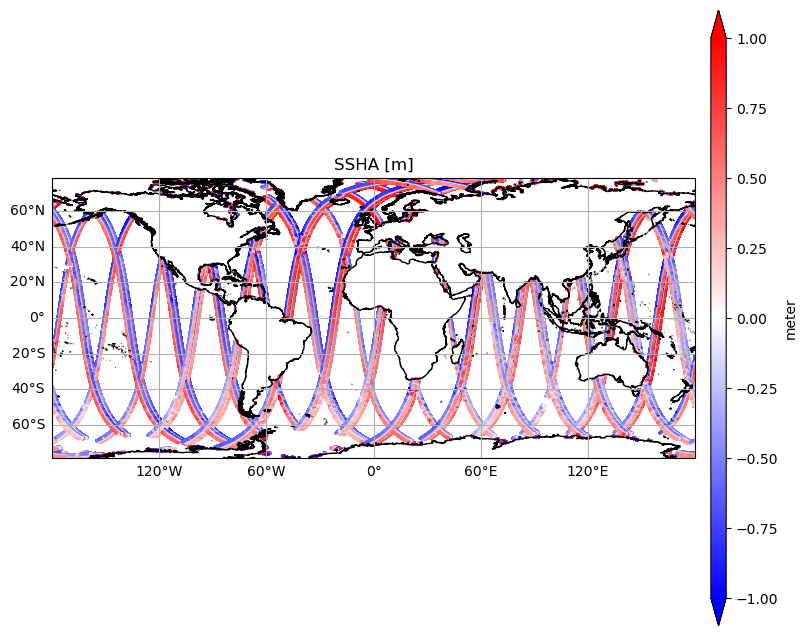

In [5]:

title = 'SSHA [m]'
lon = _ds.longitude.values
lat = _ds.latitude.values
dat = _ds.ssha_karin.values

vmin, vmax = -1,1
plotting.plot_segments(lon,lat,dat,title,vmin,vmax)

## Single track analysis


In [13]:
# Tests with 1 file
test = datasets[0]
test

<xarray.Dataset> Size: 128MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines, num_pixels) datetime64[ns] 5MB ...
    time_tai                               (num_lines, num_pixels) datetime64[ns] 5MB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-08T16:17:27Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.80712455934498
    ssha_variance:                                 0.026332454950334927
    references:                                    V1.4.1
    equator_longitude:                             4.50

(-20.0, 34.100217999999984)

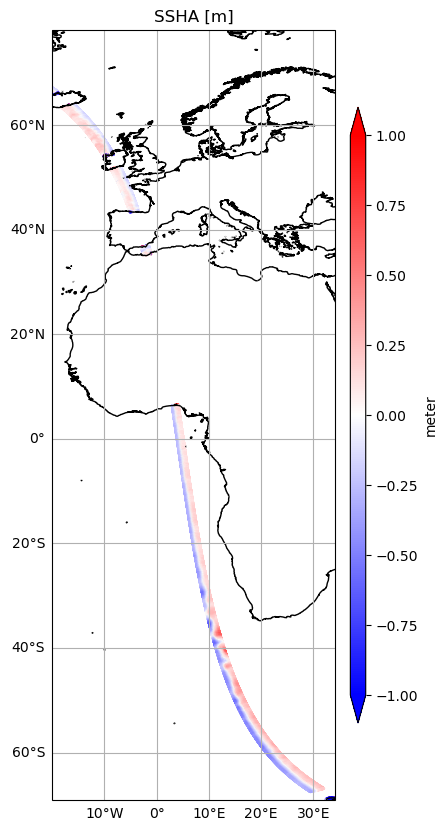

In [16]:
# Whole dataset
title = 'SSHA [m]'
dat = test.ssha_karin.where(np.isnan(test.ssha_karin)==False).values
lon = test.longitude.where(np.isnan(dat)==False).values
lat = test.latitude.where(np.isnan(dat)==False).values
vmin, vmax = -1,1

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,lonmax)

(-60.0, -40.0)

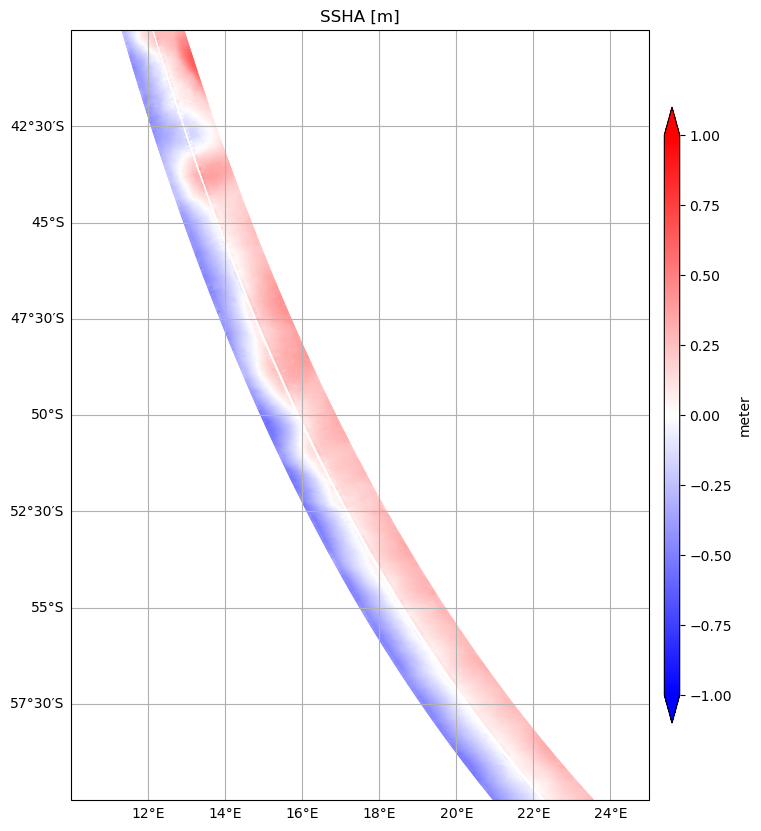

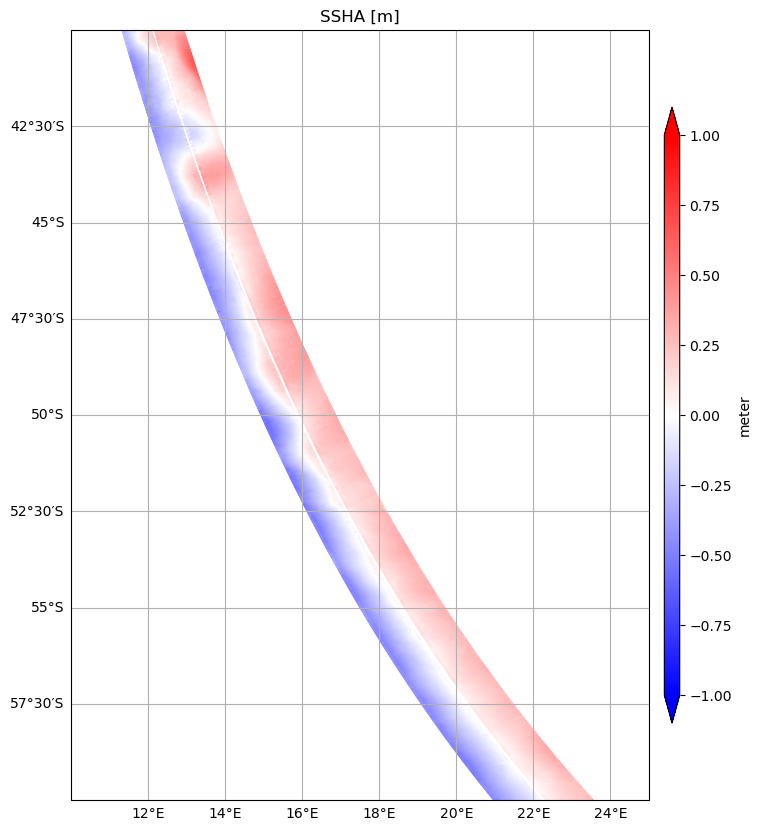

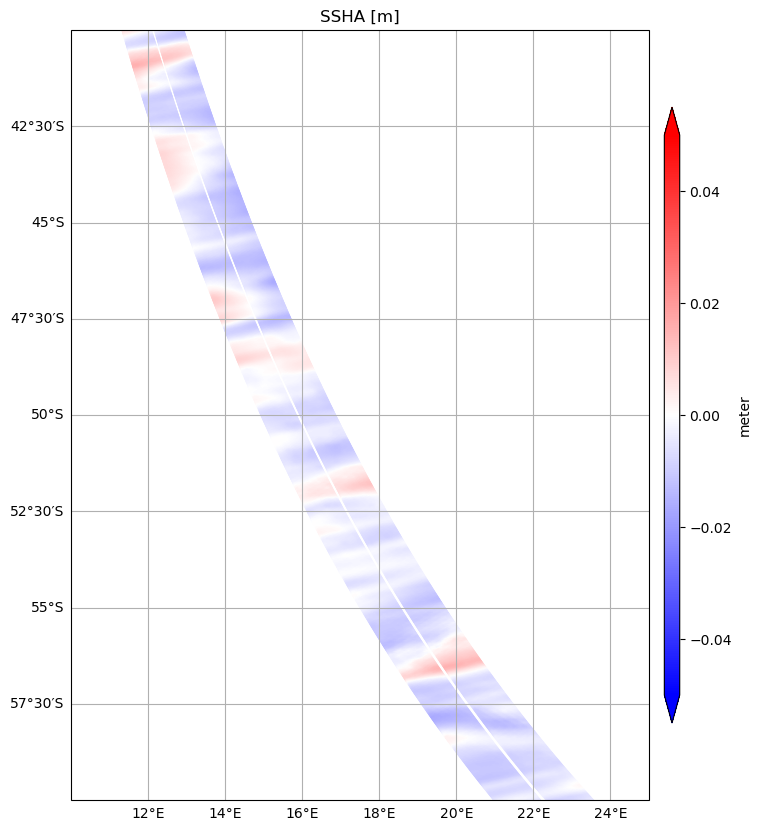

In [18]:
# Zooming in SSHA close to the Alghulas current

title = 'SSHA [m]'
lon = test.longitude.values
lat = test.latitude.values
dat = test.ssha_karin.values
vmin, vmax = -1,1

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)


dat = test.ssha_karin_2.values


vmin, vmax = -1,1

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

dat = (test.ssha_karin-test.ssha_karin_2).values

vmin, vmax = -1,1

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,-0.05,0.05)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

(-60.0, -40.0)

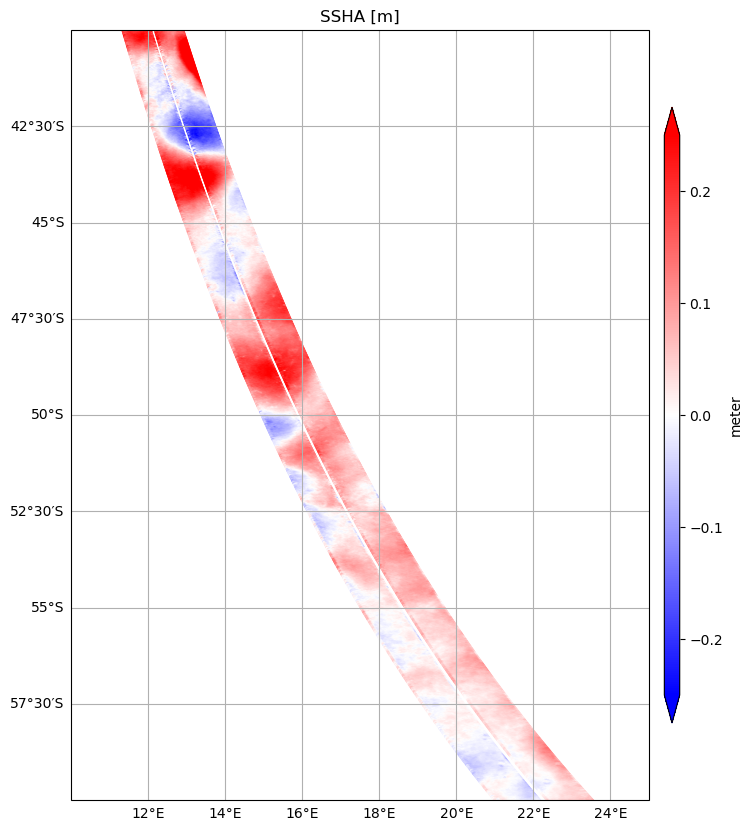

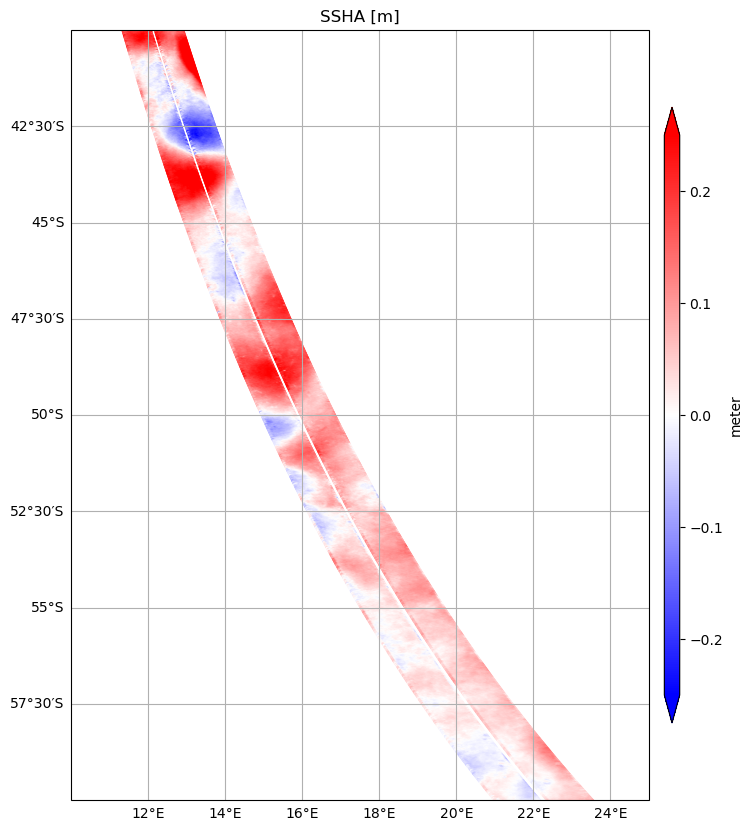

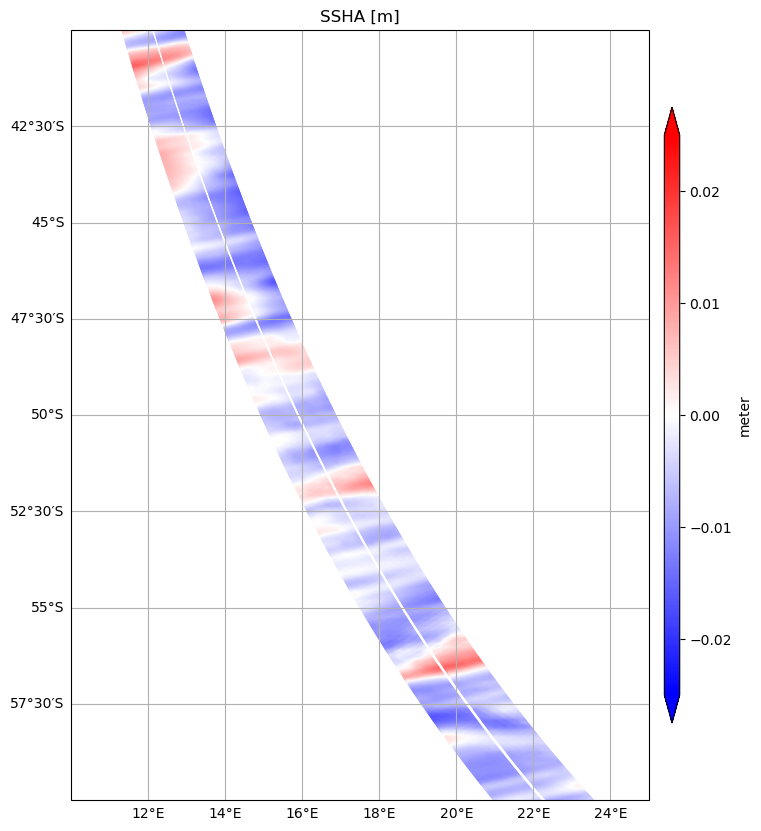

In [19]:
# Correcting the crossover bias using exisitng height correction in Basic files
dat = (test.ssha_karin + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

dat = (test.ssha_karin_2 + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

dat = (test.ssha_karin-test.ssha_karin_2).values

vmin, vmax = -0.025,0.025

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

(50.0, 65.0)

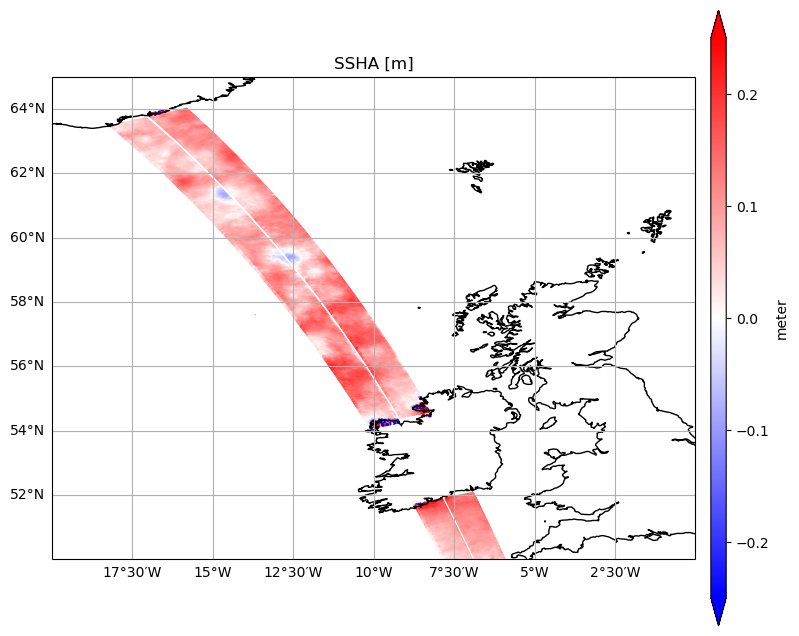

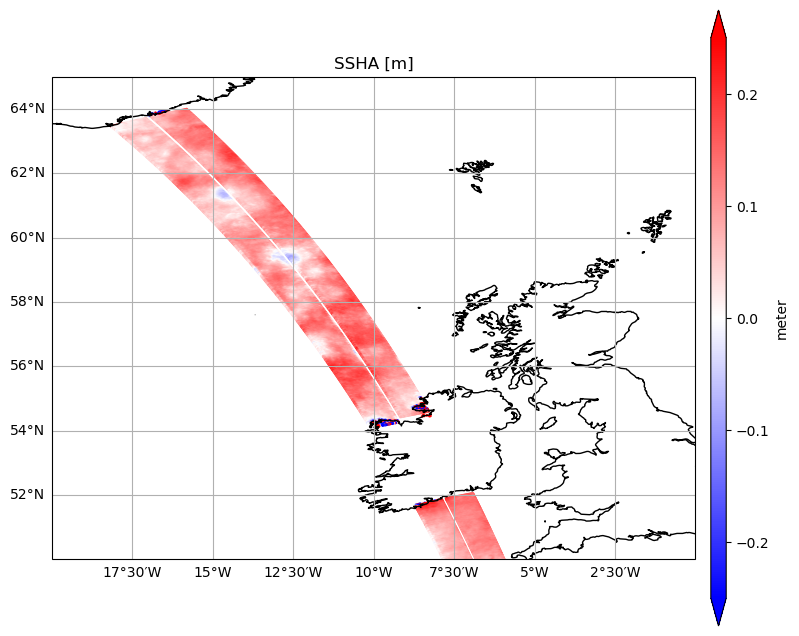

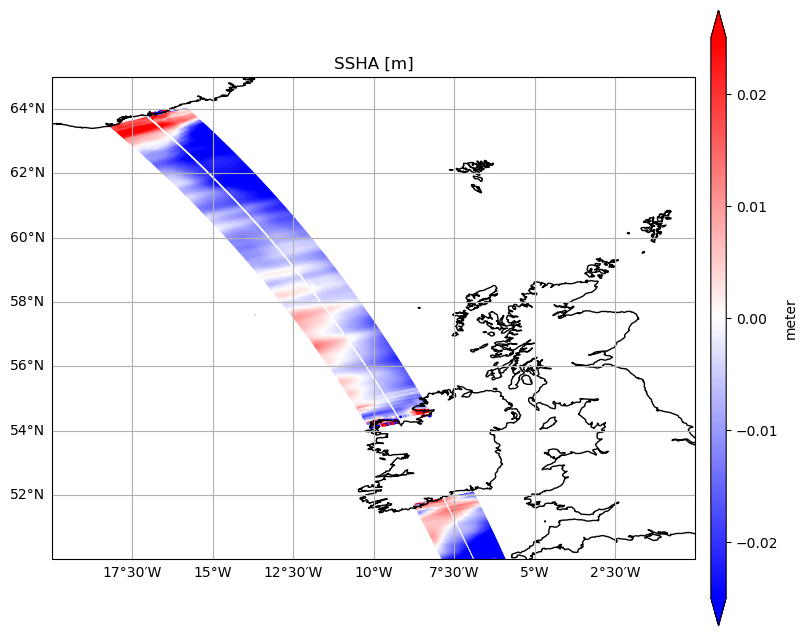

In [20]:
# Same analysis south of Iceland
dat = (test.ssha_karin + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)

dat = (test.ssha_karin_2 + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)

dat = (test.ssha_karin-test.ssha_karin_2).values

vmin, vmax = -0.025,0.025

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)